# **This model would be for predicting the health of the traffic systemm we have build in Lanezy**

# Install Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Loading CSV

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head()

,voltage,packet_loss,response_time,sensor_health,system_health_percent
0,5.248357,0.079744,103.535360,0.814177,84.403220
1,4.930868,0.085613,105.291072,0.825894,78.035271
2,5.323844,0.139587,103.052094,0.981838,76.335561
3,5.761515,0.099863,88.809769,0.724123,81.578221
4,4.882923,0.074480,98.943619,0.877963,85.315525


# Comparing Quantities

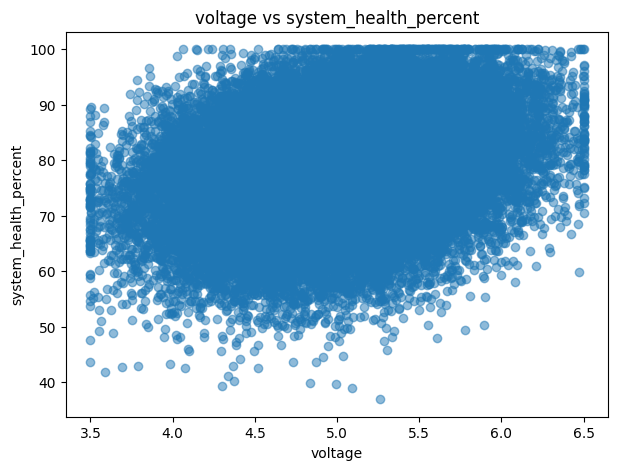

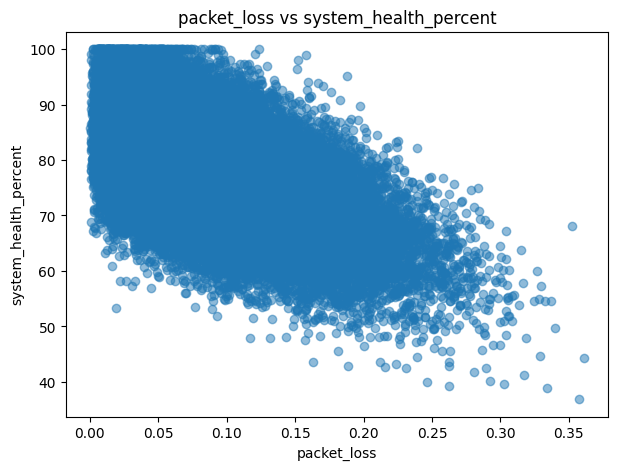

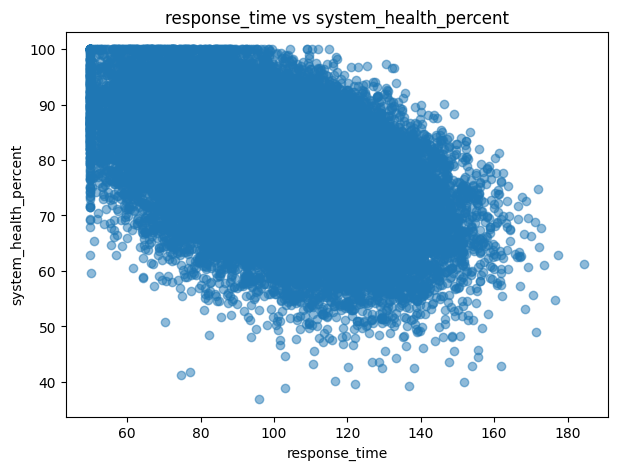

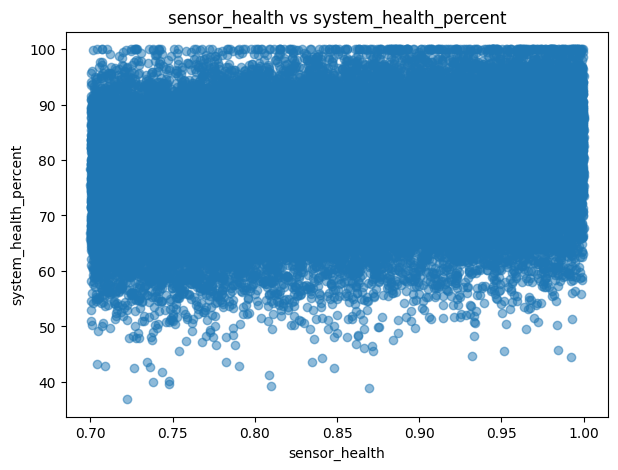

In [4]:
# Target column
target = "system_health_percent"

# Loop through each feature and plot against target
for col in df.columns:
    if col != target:
        plt.figure(figsize=(7,5))
        plt.scatter(df[col], df[target], alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{col} vs {target}")
        plt.show()

# Some Basic Info

In [5]:
df.describe()

,voltage,packet_loss,response_time,sensor_health,system_health_percent
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,4.999832,0.083288,99.994714,0.849758,78.672311
std,0.498838,0.051429,19.882018,0.086812,8.712807
min,3.500000,0.000408,50.000000,0.700012,36.902472
25%,4.660687,0.043819,86.484015,0.774975,73.006792
50%,5.000870,0.074158,99.856115,0.849742,78.952328
75%,5.338530,0.113189,113.434840,0.925371,84.660166
max,6.500000,0.360855,184.387327,0.999995,100.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   voltage                50000 non-null  float64
 1   packet_loss            50000 non-null  float64
 2   response_time          50000 non-null  float64
 3   sensor_health          50000 non-null  float64
 4   system_health_percent  50000 non-null  float64
dtypes: float64(5)
memory usage: 1.9 MB


In [7]:
df.isnull().sum()

,0
voltage,0
packet_loss,0
response_time,0
sensor_health,0
system_health_percent,0


No Null Values

# Moving Forward with normalisation and splitting

In [13]:
X = df.drop("system_health_percent", axis=1)
y = df["system_health_percent"]

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure y is numpy array
y_array = np.array(y).reshape(-1, 1)

# Split before scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y_array, test_size=0.3, random_state=42
)

# Scale X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)


# Trying out different ML Models

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor()
}

In [15]:
from sklearn.metrics import mean_squared_error, r2_score


results = {}

# Training & Evaluation
for name, model in models.items():
    model.fit(X_train_scaled, y_train_scaled)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test_scaled, y_pred)
    r2 = r2_score(y_test_scaled, y_pred)
    results[name] = {"MSE": mse, "R2": r2}

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


                               MSE        R2
Linear Regression         0.324158  0.673969
Random Forest             0.355361  0.642586
Gradient Boosting         0.328597  0.669505
Support Vector Regressor  0.326485  0.671629
K-Nearest Neighbors       0.392705  0.605026


Linear Regression Performs best

# Hyper parameter Tuning

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Pipeline with placeholder regressor (will be replaced in param_grid)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("regressor", Ridge())
])

# Grid search parameters
param_grid = [
    {
        "poly__degree": [1, 2, 3],
        "regressor": [Ridge()],
        "regressor__alpha": [0.01, 0.1, 1, 10, 100]
    },
    {
        "poly__degree": [1, 2, 3],
        "regressor": [Lasso(max_iter=10000)],
        "regressor__alpha": [0.01, 0.1, 1, 10, 100]
    },
    {
        "poly__degree": [1, 2, 3],
        "regressor": [ElasticNet(max_iter=10000)],
        "regressor__alpha": [0.01, 0.1, 1, 10, 100],
        "regressor__l1_ratio": [0.2, 0.5, 0.8]  # balance between L1 and L2
    }
]

# Grid Search
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search.fit(X_train, y_train)

# Best results
print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Best CV R² Score:", grid_search.best_score_)

# Evaluate on Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("✅ Test R²:", test_r2)
print("✅ Test RMSE:", test_rmse)


Fitting 5 folds for each of 75 candidates, totalling 375 fits
✅ Best Parameters: {'poly__degree': 1, 'regressor': Ridge(), 'regressor__alpha': 10}
✅ Best CV R² Score: 0.6717119362348678
✅ Test R²: 0.6739710006403243
✅ Test RMSE: 4.964840685651405


In [19]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Final pipeline with best parameters
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=1, include_bias=False)),
    ("regressor", Ridge(alpha=10))
])

# Train on full training set
final_model.fit(X_train, y_train)

# Evaluate
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("✅ Final Model (Ridge)")
print(f"Train R²: {train_r2:.4f}, Train RMSE: {train_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}, Test RMSE: {test_rmse:.4f}")


✅ Final Model (Ridge)
Train R²: 0.6719, Train RMSE: 4.9946
Test R²: 0.6740, Test RMSE: 4.9648


In [20]:
import pandas as pd

# Example new samples (replace with your real varied values)
new_data = pd.DataFrame([
    {"voltage": 4.9, "packet_loss": 0.01, "response_time": 90,  "sensor_health": 0.95},
    {"voltage": 5.2, "packet_loss": 0.05, "response_time": 110, "sensor_health": 0.85},
    {"voltage": 5.5, "packet_loss": 0.02, "response_time": 70,  "sensor_health": 0.99},
    {"voltage": 4.7, "packet_loss": 0.08, "response_time": 120, "sensor_health": 0.80},
    {"voltage": 5.0, "packet_loss": 0.00, "response_time": 100, "sensor_health": 0.90},
])

# Predict system health %
predictions = final_model.predict(new_data)

# Show results
for i, pred in enumerate(predictions, 1):
    print(f"Sample {i} Predicted System Health Percent: {pred:.2f}")


Sample 1 Predicted System Health Percent: 89.47
Sample 2 Predicted System Health Percent: 81.00
Sample 3 Predicted System Health Percent: 96.22
Sample 4 Predicted System Health Percent: 72.54
Sample 5 Predicted System Health Percent: 87.99


# Export the model

In [21]:
import joblib

# Save model
joblib.dump(final_model, "ridge_system_health_model.joblib")

print("✅ Model saved as ridge_system_health_model.joblib")


✅ Model saved as ridge_system_health_model.joblib
